In [ ]:
#Importing Packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp, solve_bvp
import scipy.constants as const

In [ ]:
#Defining Constants

G = const.G                         #Gravitational Constant
me = const.m_e                      #Electron Mass
mp = const.m_p                      #Proton Mass
h = const.h                         #Planck Constant
hbar = const.hbar                   #Reduced Planck Constant
k = const.k                         #Boltzmann Constant
o = const.Stefan_Boltzmann          #Stefan-Boltzmann Constant
c = const.c                         #Speed of light
a = 4*o/c                           #Radiative Pressure Constant
y = 5/3                             #Adiabatic Constant (Ideal Gas)
Msun = 1.989*10**30                 #Sun Mass
pi = np.pi                          #Pi
eps = 10**(-2)                      #Used to Calculate Derivatives of Pressure
Lsun = 3.828e26                     #Sun Luminosity
Rsun = 6.955e8                      #Sun Radius


X2 = 0.73                           #Hydrogen Mass Fraction
Z2 = 0.02                           #Metal Mass Fraction
Y2 = 1-X2-Z2                        #Helium Mass Fraction
u2 = (2*X2 + 0.75*Y2+0.5*Z2)**(-1)  #Mean Molecular Weight

XCNO = 0.03*X2                      #Hydrogen Mass Fraction Used in CNO Cycle



kes = 0.02*(1+X2)                   #Rosseland Mean Opacity from Electron Scattering 




In [ ]:
#Defining some equations

def Lsurf (R, T):
    """
    Returns surface luminosity

    Parameters:
    R - Star radius
    T - Surface temperature
    """
    return 4*pi*o*R*R*T**4

def epp (p, T):
    """
    Returns the energy generated by the proton-proton chain

    Parameters:
    p - Density
    T - Temperature
    """
    return 1.07*10.0**(-7.0)*(p/10.0**5.0)*X2*X2*(T/10.0**6.0)**4.0

def ecno (p, T):
    """
    Returns the energy generated by the CNO-cycle

    Parameters:
    p - Density
    T - Temperature
    """
    return 8.24*10.0**(-26.0)*(p/10.0**5.0)*X2*XCNO*(T/10.0**6.0)**19.9

def etot (p, T):
    """
    Returns the total generated energy from the proton-proton chain and the CNO cycle

    Parameters:
    p - Density
    T - Temperature
    """
    return epp(p, T) + ecno(p, T)

def kff (p, T):
    """
    Returns the Rosseland mean opacity produced by free-free absorption

    Parameters:
    p - Density
    T - Temperature
    """
    return 1.0*10**24.0*(Z2+0.0001)*(p/10.0**3.0)**(0.7)*(T)**(-3.5)

def kH (p, T):
    """
    Returns the Rosseland mean opacity produced by H- absorption

    Parameters:
    p - Density
    T - Temperature
    """
    return 2.5*10**(-32.0)*(Z2/0.02)*(p/10.0**3.0)**(0.5)*(T)**(9.0)  

def kr(p, T): 
    """
    Returns the radiative opacity. If T > 10**4 K, use the hot case. Otherwise, use the cold case

    Parameters:
    p - Density
    T - Temperature
    """
    maxval = np.maximum(kes, kff(p, T))             #Calculate max between electron scattering or free-free opacity
    minval = np.minimum(kes, kff(p, T))             #Calculate min between electron scattering or free-free opacity
    hot = (1.0/kH(p, T)+1.0/maxval)**(-1.0)         #Calculate radiative opacity in the above 10**4 K case
    cold = (1.0/kH(p, T)+1.0/minval)**(-1.0)        #Calculate radiative opacity in the below 10**4 K case
    return np.where(T > 10.0**4.0, hot, cold)       #This is a fancy, one line, if statement. If T > 10**4 K, return hot. Else, return cold


def dPdr(r, p, M):
    """
    Returns the derivative of the pressure with respect to the radius.

    Parameters:
    r - Radius
    p - Density
    M - Mass
    """
    return -G*M*p/r/r

def compute_f(p, T, M, L, P_std):
    """
    Computes the convection parameter f. 
    If the radiative gradient is larger than the adiabatic gradient, the zone is convective (f=0). Otherwise, it is radiative.

    Parameters:
    p - Density
    T - Temperature
    M - Mass
    L - Luminosity
    P_std - Pressure without considering magnetic fields
    """
    # Prevent divide-by-zero errors at the very center of the star
    if M <= 0.0 or L <= 0.0:
        return 0.0
        
    # This is the actual radiative temperature gradient
    nabla_rad = (3.0 * kr(p, T) * L * P_std) / (16.0 * pi * a * c * G * M * (T**4.0))
    
    # The adiabatic gradient nabla_ad (for our gamma)
    nabla_ad = 1.0 - (1.0 / y)
    
    if nabla_rad > nabla_ad:
        # This is a convection zone, so magnetic fields amplify.
        return 0.0
    else:
        # This is a radiative zone, so f parameter is > 0
        return abs(nabla_ad - nabla_rad)

def Pdegen(p):
    """
    Returns the degeneracy pressure of the star at a given radius

    Parameters:
    p - Density
    """
    B = hbar*hbar/me                        #hbar**2/me
    A = (3.0*pi*pi)**(2.0/3.0)/5.0*B        #Bunch of constants in front of the degenerate pressure term    
    t1 = A*(p/mp)**(5.0/3.0) 
    return t1

def Pgas(p, T):
    """
    Returns the gas pressure of the star at a given radius

    Parameters:
    p - Density
    T - Temperature 
    """
    t2 = p*k*T/u2/mp 
    return t2

def Pphoton(T):
    """
    Returns the photon pressure of the star at a given radius

    Parameters:
    T - Temperature 
    """
    t3 = 1.0/3.0*a*T**4.0  
    return t3

def P(p, T, M = 0.0, L = 0.0, mag = False, n = 1.0, beta = 10.0):
    """
    Returns the total pressure of the star at a given radius

    Parameters:
    p - Density
    T - Temperature 
    M - Mass (default = 0.0)
    L - Luminosity (default = 0.0)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    B = hbar*hbar/me                        #hbar**2/me
    A = (3.0*pi*pi)**(2.0/3.0)/5.0*B        #Bunch of constants in front of the degenerate pressure term    
    t1 = A*(p/mp)**(5.0/3.0)                #Degenerate Pressure
    t2 = p*k*T/u2/mp                        #Gas Pressure
    t3 = 1.0/3.0*a*T**4.0                   #Photon Pressure
    Pstd = t1 + t2 + t3                     #Total Pressure (without magnetic fields)
    if mag:
        f = compute_f(p, T, M, L, Pstd)     #Calculate f
        Pmag = t2/(f**n+beta)               #Magnetic Pressure
        return Pstd + Pmag                  #Total Pressure (with magnetic fields)
    return Pstd

def dPdp(p, T, M = 0.0, L = 0.0, mag = False, n = 1.0, beta = 10.0):
    """
    Returns the derivative of the pressure with respect to the density at a given radius

    Parameters:
    p - Density
    T - Temperature 
    M - Mass (default = 0.0)
    L - Luminosity (default = 0.0)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    if mag:
        # Using numerical derivative for B fields
        # Will incrementally change the density up and down by a tiny fraction (eps)
        # This part was written by Ziad
        P1 = P(p * (1.0 + eps), T, M, L, mag, n, beta)
        P2 = P(p * (1.0 - eps), T, M, L, mag, n, beta)
        return (P1 - P2) / (2.0 * p * eps)
    
    B = hbar*hbar/me                            #hbar**2/me
    A = (3.0*pi*pi)**(2.0/3.0)/3.0*B/mp         #Bunch of constants in front of the degenerate pressure term 
    t1 = A*(p/mp)**(2.0/3.0)                    #Degenerate Pressure Derivative Term
    t2 = k*T/u2/mp                              #Gas Pressure Derivative Term
    return t1+t2

def dPdT(p, T, M = 0.0, L = 0.0, mag = False, n = 1.0, beta = 10.0):
    """
    Returns the derivative of the pressure with respect to the temperature at a given radius

    Parameters:
    p - Density
    T - Temperature 
    M - Mass (default = 0.0)
    L - Luminosity (default = 0.0)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    if mag:
        # Same thing we did for dP/dp but this time with temperature
        # This part was written by Ziad
        P1 = P(p, T * (1.0 + eps), M, L, mag, n, beta)
        P2 = P(p, T * (1.0 - eps), M, L, mag, n, beta)
        return  (P1 - P2) / (2.0 * T * eps)
    
    t1 = p*k/u2/mp                  #Gas Pressure Derivative Term
    t2 = 4.0/3.0*a*T**3.0           #Photon Pressure Derivative Term
    return t1+t2





In [ ]:
#Defining our equations of integration

def dTdr(r, M, p, L, T, mag = False, n = 1.0, beta = 10.0):
    """
    Returns the derivative of the temperature with respect to the radius at a given radius. 
    Uses the smaller magnitude (flatter) between radiative and convective energy transport

    Parameters:
    r - Radius
    M - Mass
    p - Density
    L - Luminosity
    T - Temperature
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    d1 = 3.0*kr(p, T)*p*L/16.0/pi/a/c/T**3.0/r/r                #Radiative Transport
    d2 = (1.0-1.0/y)*T*G*M*p/P(p, T, M, L, mag, n, beta)/r/r    #Convective Transport
    if np.isnan(d1) or np.isnan(d2):                            #This if statement is just a debugger - large steps in the integrator often returns NAN
        print("NANS")
    return -min(abs(d1), abs(d2))
    

def dpdr(r, M, p, L, T, mag = False, n = 1.0, beta = 10.0):
    """
    Returns the derivative of the density with respect to the radius at a given radius. 

    Parameters:
    r - Radius
    M - Mass
    p - Density
    L - Luminosity
    T - Temperature
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    return -(G*M*p/r/r+dPdT(p, T, M, L, mag, n, beta)*dTdr(r, M, p, L, T, mag, n, beta))/dPdp(p, T, M, L, mag, n, beta)

def dMdr(r, p):
    """
    Returns the derivative of the mass with respect to the radius at a given radius. 

    Parameters:
    r - Radius
    p - Density
    """
    return 4.0*pi*r*r*p

def dLdrpp(r, p, T):
    """
    Returns the derivative of the luminosity with respect to the radius, using only PP-Chain energy generation, at a given radius. 

    Parameters:
    r - Radius
    p - Density
    T - Temperature
    """
    return 4.0*pi*r*r*p*epp(p, T)

def dLdrcno(r, p, T):
    """
    Returns the derivative of the luminosity with respect to the radius, using only CNO cycle energy generation, at a given radius. 

    Parameters:
    r - Radius
    p - Density
    T - Temperature
    """
    return 4.0*pi*r*r*p*ecno(p, T)

def dLdr(r, p, T):
    """
    Returns the derivative of the luminosity with respect to the radius at a given radius. 

    Parameters:
    r - Radius
    p - Density
    T - Temperature
    """
    return 4.0*pi*r*r*p*etot(p, T)

def dtaudr(p, T):
    """
    Returns the derivative of the optical depth with respect to the radius at a given radius. 

    Parameters:
    p - Density
    T - Temperature
    """
    return kr(p, T)*p


def eqofss(r, z, mag = False, n = 1.0, beta = 10.0):    
    """
    Returns a lists of the derivatives of all the natural variables: temperature, density, mass, luminosity, and optical depth

    Parameters:
    r - Radius
    z - List of State Variables (Temperature, Density, Mass, Luminosity, and Optical Depth)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    T, p, M, L, tau = z                         #Unpacking the list to corresponding variables
    dT = dTdr(r, M, p, L, T, mag, n, beta)      #Calculating the derivatives of the variables
    dp = dpdr(r, M, p, L, T, mag, n, beta)
    dM = dMdr(r, p)
    dL = dLdr(r, p, T)
    dtau = dtaudr(p, T)
    return [dT, dp, dM, dL, dtau]

In [ ]:
#solve the equations

def M0(r0, pc):
    """
    Returns the initial mass of the star contained at a radius near the center 

    Parameters:
    r0 - Initial radius
    pc - Central density of the star
    """
    return 4.0*pi/3.0*r0**3.0*pc

def L0(r0, pc, Tc):
    """
    Returns the initial luminosity of the star contained at a radius near the center 

    Parameters:
    r0 - Initial radius
    pc - Central density of the star
    Tc - Central temperature of the star
    """
    return 4.0*pi/3.0*r0**3.0*pc*etot(pc, Tc)

def Mmax(r, z, mag = False, n = 1.0, beta = 10.0):
    """
    Function to determine if the integrator should terminate given if the total star mass exceeds 1000 solar masses

    Parameters:
    r - Radius
    z - List of State Variables (Temperature, Density, Mass, Luminosity, and Optical Depth)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    return z[2] - 10.0**3.0*Msun           #Returns the difference between the star mass and 1000 solar masses. Terminates if this is less than 0

Mmax.terminal = True        #This is allowing the Mmax function to terminate the integrator

def deltatau(r, z, mag = False, n = 1.0, beta = 10.0):
    """
    Function to determine if the integrator should terminate given if delta tau is much smaller than one (δτ << 1)

    Parameters:
    r - Radius
    z - List of State Variables (Temperature, Density, Mass, Luminosity, and Optical Depth)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    diff = 10.0**(-3.0)                                                                     #Setting the target delta tau value
    val = kr(z[1], z[0])*z[1]*z[1]/abs(dpdr(r, z[2], z[1], z[3], z[0], mag, n, beta))       #Calculating delta tau
    return val - diff                                                                       #Returns the difference between delta tau and the target values. Terminates if this is less than 0

deltatau.terminal = True    ##This is allowing the deltatau function to terminate the integrator

def solver(pc, Tc, r0 = 10.0, R = 10.0**10, mag = False, n = 1.0, beta = 10.0):
    """
    Integrates the equations of stellar structure using scipy.integrate.solve_ivp(). Returns the result of scipy.integrate.solve_ivp()

    Parameters:
    pc - Central density of the star
    Tc - Central temperature of the star
    r0 - Initial radius (default = 10.0)
    R - Max radius (default = 10.0**10)
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    rlim = [r0, R]                          #Setting the bounds of integration
    Mc = M0(r0, pc)                         #Calculating the initial conditions
    Lc = L0(r0, pc, Tc)
    tauc = 0.0
    z0 = np.array([Tc, pc, Mc, Lc, tauc])   #Creating an array of the initial conditions 
    sol = solve_ivp(eqofss, rlim, z0,  events = (Mmax, deltatau), method= 'RK45', args=(mag, n, beta), first_step = 1.0*10**4, rtol = 1.0e-7, atol = 1.0e-10, max_step = 7.0e6)
    return sol


###Some test cases are below.
# .message returns what caused integration to terminate
# .t returns the radius values
# .y returns the corresponding values of the natural varibles

# teststar = solver(58.556*1000,1e6, mag = True, n = 1, beta = 10)
# print(teststar.message)
# print(teststar.t)
# print(teststar.y)

# teststar = solver(58.556*1000, 1e6)
# print(teststar.message)
# print(teststar.t)
# print(teststar.y)





In [6]:
## Finding a suitable value for the central density

pmin = 0.3*1000.0           #Minimum density value for bisection
pmax = 500.0 * 1000.0       #Maximum density value for bisection

def tauR(tau):
    """
    Returns the index of the star's radius (not the radius itself) using the surface condition:
    tau(infinity) - tau(star radius) = 2/3

    Parameters:
    tau - list of tau values generated by solver()
    """ 
    tau = np.array(tau)
    indexmax = len(tau) - 1
    tauinf = tau[indexmax]                      #Finding tau inifinity (last tau value in list)
    tauRval = tauinf                            #Setting a value for tau at the star's radius
    Rstarindex = 0                              #Setting an index for tau at the star's radius
    for i in range(indexmax-1):                 #Calculates the Rstarindex by finding the min of abs(tau(infinity) - tau(star radius) - 2/3)
        test = abs(tauinf-tau[i]-2.0/3.0)       
        if test < tauRval:
            tauRval = test                      #Sets new tau value if smaller than original tau value
            Rstarindex = i                      #Sets new index value using index of smaller tau value

    return Rstarindex

def RStarvals(sol):
    """
    Returns the value of the star's radius and other natural variables at the star's radius using tauR()
    List order: Temperture, Density, Mass, Luminosity, Optical Depth, Radius
    
    Parameters:
    sol - default return value of scipy.integrate.solve_ivp() 
    """
    Rs = sol.t              #Separating sol into respective radius, temperature, density, mass, luminosity, and optical depth values.
    Ts = sol.y[0]
    ps = sol.y[1]
    Ms = sol.y[2]
    Ls = sol.y[3]
    taus = sol.y[4]
    Rstarindex = tauR(taus) #Finding index of star surface
    return [Ts[Rstarindex], ps[Rstarindex], Ms[Rstarindex], Ls[Rstarindex], taus[Rstarindex], Rs[Rstarindex]]


def fofpc(sol):
    """
    Returns the error between the calculated luminosity from Stefan-Boltzmann and the luminosity found through integration

    Parameters:
    sol - default return value of scipy.integrate.solve_ivp() 
    """
    starvals = RStarvals(sol)                   #Finding star surface values
    Tstar = starvals[0]
    Lstar = starvals[3]
    Rstar = starvals[5]
    Lcalc = 4*pi*o*Rstar*Rstar*Tstar**4.0       #Calculating luminosity from Stefan-Boltzmann
    return (Lstar-Lcalc)/np.sqrt(Lstar*Lcalc)


def pcroot(Tc, ftol = 10**(-4), ptol = 10**(-4), mag = False, n = 1.0, beta = 10.0):
    """
    Returns the values at a star's surface with a given central temperature by finding the root of fofpc()

    Parameters:
    Tc - Central Density
    ftol - Target Value to Find Root of fofpc() (default = 2*10**(-2))
    ptol - Target Value of Central Density Difference Between Upper and Lower Bounds (default = 2*10**(-2))
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    
    plower = pmin                                                   #Setting upper, lower, and mid densities and star solutions
    lower = solver(plower, Tc, mag = mag, n = n, beta = beta)
    pupper = pmax
    upper = solver(pupper, Tc, mag = mag, n = n, beta = beta)
    pmid = 0.5*(plower+pupper)
    mid = solver(pmid, Tc, mag = mag, n = n, beta = beta)


    fmid = fofpc(mid)                                               #Finding fofpc() at middle density

    while abs(fmid) > ftol and abs(plower-pupper) > ptol:
        if fmid > 0:                                                #If fofpc() > 0, then the mid density is new upper bound
            upper = mid
            pupper = pmid
        else:                                                       #If fofpc() < 0, then the mid density is new lower bound
            lower = mid
            plower = pmid
        
        pmid = 0.5*(plower+pupper)                                  #Finding new middle values
        mid = solver(pmid, Tc, mag = mag, n = n, beta = beta)
        fmid = fofpc(mid)
        
    
    
    lower = solver(plower, Tc, mag = mag, n = n, beta = beta)       #Recalculates the solution at all bounds (probably unnecessary)
    mid = solver(pmid, Tc, mag = mag, n = n, beta = beta)
    upper = solver(pupper, Tc, mag = mag, n = n, beta = beta)
    

    boundlist = [lower, mid, upper]                                 
    bestf = 100
    best = lower
    for i in boundlist:                                             #Finds lowest value of fofpc() at all bounds
        if abs(fofpc(i)) < bestf:
            bestf = abs(fofpc(i))
            best = i
    
    bestvals = RStarvals(best)                                      #Finds the values of all variables at star surface

    return bestvals



In [ ]:
def generate_main_sequence(Tc_list, mag = False, n = 1.0, beta = 10.0):
    """
    Iterates over a list of central temperatures, finds the converged 
    stellar structure using pcroot(), and extracts the surface variables.

    Parameters: 
    Tc_list - List of central temperatures used to generate a stellar solution
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    # Lists to store the extracted sequence variables
    L_seq = []
    T_surf_seq = []
    M_seq = []
    R_seq = []
    
    print("\nGenerating Main Sequence.")
    for Tc in Tc_list:
        print(f"Solving for star with T_c = {Tc:.2e} K...")
        
        # pcroot() returns the RStarvals array: [Ts, ps, Ms, Ls, taus, Rs], extracting the physical parameters at the surface
        T_ode, P_star, M_star, L_star, tau_star, R_star = pcroot(Tc, mag = mag, n = n, beta = beta)
        
        
        # Set the boundary condition by hand
        T_eff = (L_star / (4 * pi * o * (R_star**2)))**(0.25)
        
        # Convert to Solar Units for plotting
        L_seq.append(L_star / 3.828e26)
        T_surf_seq.append(T_eff)
        M_seq.append(M_star / Msun)
        R_seq.append(R_star / 6.955e8)
        
        print(f"Success! Mass: {M_star/Msun:.2f} M_sun | T_eff: {T_eff:.0f} K")
        
    return T_surf_seq, L_seq, M_seq, R_seq


def plot_main_sequence(vals, list = [], string = '', title = ''):  #"T_surf_seq, L_seq, M_seq, R_seq"
    """
    Takes the solar-unit sequence lists and generates the three plots

    Parameters:
    vals - List of T_surf_seq, L_seq, M_seq, R_seq
    list - List of variational parameters, such as n and beta (default = [])
    string - String containing the name of the variational parameters (default = '')
    title - String containing an addition to the title of the plots (default = '')
    """
    # Plot 1: HR Diagram
    temps = [30000, 10000, 7500, 6000, 5200, 3700, 2400, 1500, 1000]
    spectraltypes = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'L', 'T']

    fig, ax = plt.subplots(figsize=(8, 6))
    if len(vals) < 2:                                                #Graph Formatting                               
        T_surf_seq, L_seq, M_seq, R_seq = vals[-1]
        ax.scatter(T_surf_seq, L_seq, marker='o')
    else:
        T_surf_seq, L_seq, M_seq, R_seq = vals[-1]
        ax.scatter(T_surf_seq, L_seq, marker='o', linestyle='-', label = "Unchanged Main Sequence")
        for i in range(len(vals)-1):
            T_surf_seq, L_seq, M_seq, R_seq = vals[i]
            ax.scatter(T_surf_seq, L_seq, marker='o', linestyle='-', label = f"{string} = {list[i]:.2f}")
        

    ax.invert_xaxis()  # HR Diagrams have temperature decreasing to the right
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.set_xlabel('Effective Surface Temperature (K)')
    ax.set_xscale('log')
    ax.set_xlim(60000, 1000)
    
    bottom = ax.secondary_xaxis("bottom")
    bottom.set_xscale("log")
    bottom.set_xticks(temps)
    bottom.set_xticklabels(spectraltypes)




    ax.set_yscale('log')
    ax.set_ylabel(r'Luminosity ($L / L_\odot$)') 
    
    ax.set_title('Main Sequence: HR Diagram' + title)
    
    ax.legend()
    ax.grid(True, which="both", ls="--", alpha=0.5)


    

    # Plot 2: Mass-Luminosity Relation
    plt.figure(figsize=(8, 6))
    if len(vals) < 2:                                                       #Graph formatting
        T_surf_seq, L_seq, M_seq, R_seq = vals[-1]
        plt.plot(M_seq, L_seq, marker='o', linestyle='-')
    else:
        T_surf_seq, L_seq, M_seq, R_seq = vals[-1]
        plt.plot(M_seq, L_seq, marker='o', linestyle='-', label = "Unchanged Main Sequence")
        for i in range(len(vals)-1):
            T_surf_seq, L_seq, M_seq, R_seq = vals[i]
            plt.plot(M_seq, L_seq, marker='o', linestyle='-', label = f"{string} = {list[i]:.2f}")
        
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Mass ($M / M_\odot$)')
    plt.ylabel(r'Luminosity ($L / L_\odot$)')
    plt.title('Main Sequence: Mass-Luminosity Relation' + title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()

    # Plot 3: Mass-Radius Relation
    plt.figure(figsize=(8, 6))
    if len(vals) < 2:                                                         #Graph formatting
        T_surf_seq, L_seq, M_seq, R_seq = vals[-1]
        plt.plot(M_seq, R_seq, marker='o', linestyle='-')
    else:
        T_surf_seq, L_seq, M_seq, R_seq = vals[-1]
        plt.plot(M_seq, R_seq, marker='o', linestyle='-', label = "Unchanged Main Sequence")
        for i in range(len(vals)-1):
            T_surf_seq, L_seq, M_seq, R_seq = vals[i]
            plt.plot(M_seq, R_seq, marker='o', linestyle='-', label = f"{string} = {list[i]:.2f}")
        
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Mass ($M / M_\odot$)')
    plt.ylabel(r'Radius ($R / R_\odot$)')
    plt.title('Main Sequence: Mass-Radius Relation' + title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()




Generating Main Sequence.
Solving for star with T_c = 1.00e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1081 K
Solving for star with T_c = 1.04e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1126 K
Solving for star with T_c = 1.08e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1172 K
Solving for star with T_c = 1.13e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1173 K
Solving for star with T_c = 1.17e+06 K...
Success! Mass: 0.09 M_sun | T_eff: 1244 K
Solving for star with T_c = 1.22e+06 K...
Success! Mass: 0.09 M_sun | T_eff: 1324 K
Solving for star with T_c = 1.27e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1175 K
Solving for star with T_c = 1.32e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1252 K
Solving for star with T_c = 1.37e+06 K...
Success! Mass: 0.09 M_sun | T_eff: 1325 K
Solving for star with T_c = 1.43e+06 K...
Success! Mass: 0.09 M_sun | T_eff: 1367 K
Solving for star with T_c = 1.48e+06 K...
Success! Mass: 0.08 M_sun | T_eff: 1271 K
Solving for star with T_c = 1.54e+06 K...
Success

C:\Users\matth\AppData\Local\Temp\ipykernel_23876\3612436701.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\matth\AppData\Local\Temp\ipykernel_23876\3612436701.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


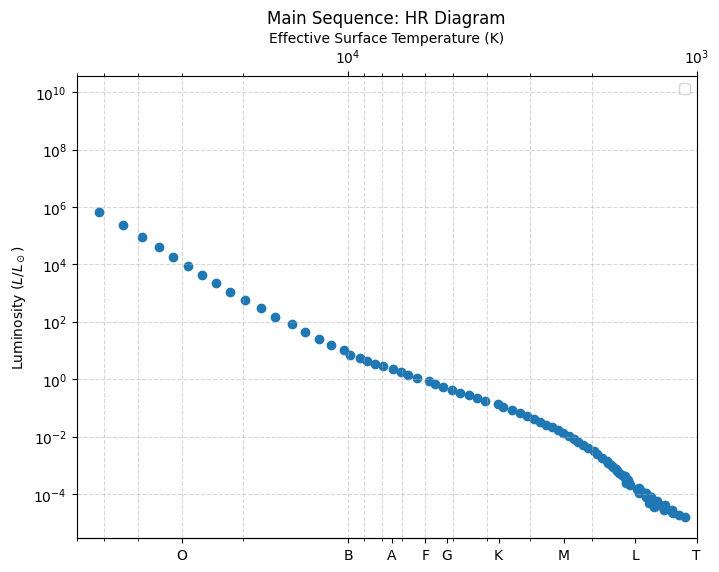

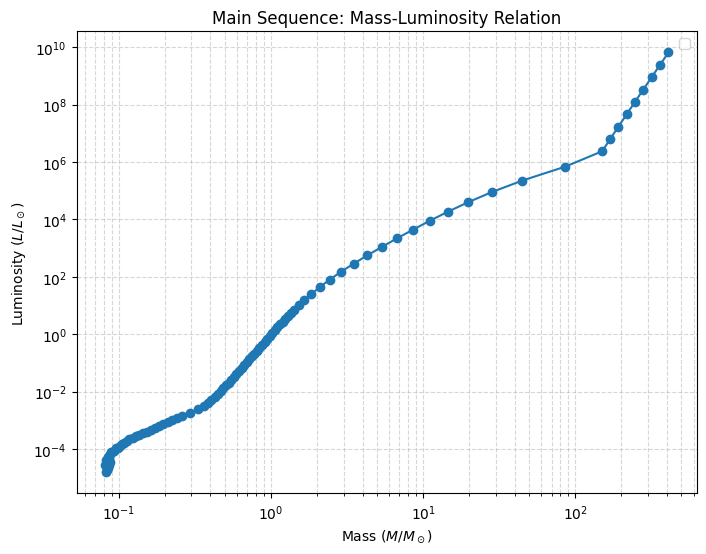

C:\Users\matth\AppData\Local\Temp\ipykernel_23876\3612436701.py:136: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


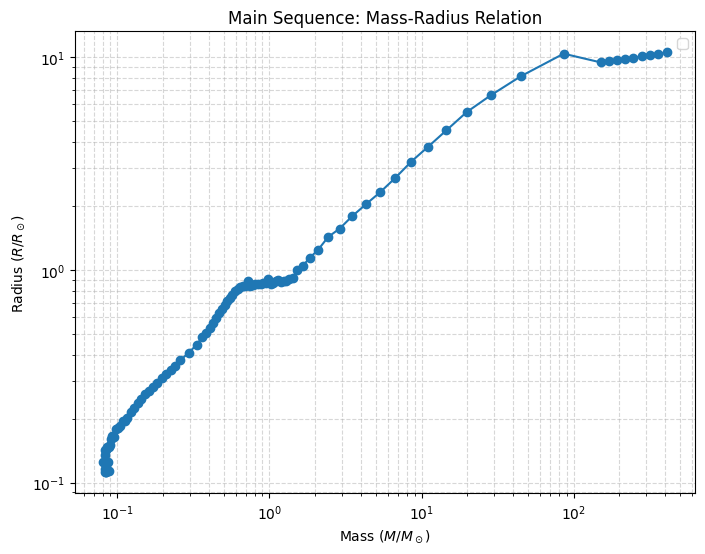

In [ ]:
# EXECUTION PIPELINE

Tc_list =  np.geomspace(1e6, 5e7, 100)                      #Change the 100 to a smaller value (5, 10) for a shorter generation time (less stars)

# Generate the sequence

[T_surf, Ls, Ms, Rs] = generate_main_sequence(Tc_list)


# Generate the plots

plot_main_sequence([[T_surf, Ls, Ms, Rs]])



In [ ]:
#List of temperatures for varying n and beta

Tc_list =  np.geomspace(1e6, 5e7, 20)                       #Change the 20 to a smaller value (5, 10) for a shorter generation time (less stars)

nlist = np.linspace(1, 3, 5)                                #Not as necessary, but 5 can be changed to 3 for less stars and faster times
nvals = []
for n in nlist:                                             #Generate a main sequence for each n value
    [T_surf, Ls, Ms, Rs] = generate_main_sequence(Tc_list, mag = True, n = n, beta = 100.0)
    nvals.append([T_surf, Ls, Ms, Rs])
[T_surf, Ls, Ms, Rs] = generate_main_sequence(Tc_list)
nvals.append([T_surf, Ls, Ms, Rs])

plot_main_sequence(nvals, nlist, "n", ' for Varying n at β = 100.0')

betalist = np.geomspace(10, 10**3, 5)                       #Not as necessary, but 5 can be changed to 3 for less stars and faster times
betavals = []
for beta in betalist:                                       #Generate a main sequence for each beta value
    [T_surf, Ls, Ms, Rs] = generate_main_sequence(Tc_list, mag = True, n = 2.0, beta = beta)
    betavals.append([T_surf, Ls, Ms, Rs])
[T_surf, Ls, Ms, Rs] = generate_main_sequence(Tc_list)
betavals.append([T_surf, Ls, Ms, Rs])

plot_main_sequence(betavals, betalist, "β", ' for Varying β at n = 2.0')

Inidividual Star Analysis

In [8]:
def VariableLists(sol):
    """
    Returns the lists of radii and other natural variables at the each radius using tauR()
    List order: Temperture, Density, Mass, Luminosity, Optical Depth, Radius

    Parameters:
    sol - default return value of scipy.integrate.solve_ivp() 
    """
    Rs = np.array(sol.t)              #Separating sol into respective radius, temperature, density, mass, luminosity, and optical depth values.
    Ts = np.array(sol.y[0])
    ps = np.array(sol.y[1])
    Ms = np.array(sol.y[2])
    Ls = np.array(sol.y[3])
    taus = np.array(sol.y[4])
    Rstarindex = tauR(taus) #Finding index of star surface
    return np.array([Ts[:Rstarindex+1], ps[:Rstarindex+1], Ms[:Rstarindex+1], Ls[:Rstarindex+1], taus[:Rstarindex+1], Rs[:Rstarindex+1]])

def pcrootlist(Tc, ftol = 2*10**(-2), ptol = 2*10**(-2), mag = False, n = 1.0, beta = 10.0):
    """
    Returns the lists of a star's values with a given central temperature by finding the root of fofpc(). 
    This is a copy of pcrootlist but will produce entire lists (from center to surface), instead of just surface

    Parameters:
    Tc - Central Density
    ftol - Target Value to Find Root of fofpc() (default = 2*10**(-2))
    ptol - Target Value of Central Density Difference Between Upper and Lower Bounds (default = 2*10**(-2))
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    
    plower = pmin                                                   #Setting upper, lower, and mid densities and star solutions
    lower = solver(plower, Tc, mag = mag, n = n, beta = beta)
    pupper = pmax
    upper = solver(pupper, Tc, mag = mag, n = n, beta = beta)
    pmid = 0.5*(plower+pupper)
    mid = solver(pmid, Tc, mag = mag, n = n, beta = beta)


    fmid = fofpc(mid)                                               #Finding fofpc() at middle density

    while abs(fmid) > ftol and abs(plower-pupper) > ptol:
        if fmid > 0:                                                #If fofpc() > 0, then the mid density is new upper bound
            upper = mid
            pupper = pmid
        else:                                                       #If fofpc() < 0, then the mid density is new lower bound
            lower = mid
            plower = pmid
        
        pmid = 0.5*(plower+pupper)                                  #Finding new middle values
        mid = solver(pmid, Tc, mag = mag, n = n, beta = beta)
        fmid = fofpc(mid)
        
    
    
    lower = solver(plower, Tc, mag = mag, n = n, beta = beta)       #Recalculates the solution at all bounds (probably unnecessary)
    mid = solver(pmid, Tc, mag = mag, n = n, beta = beta)
    upper = solver(pupper, Tc, mag = mag, n = n, beta = beta)
    

    boundlist = [lower, mid, upper]                                 
    bestf = 100
    best = lower
    for i in boundlist:                                             #Finds lowest value of fofpc() at all bounds
        if abs(fofpc(i)) < bestf:
            bestf = abs(fofpc(i))
            best = i
    
    bestvals = VariableLists(best)                                      #Finds the values of all variables at star surface

    return bestvals


In [ ]:
lowmass = pcrootlist(8.12e6)            #Some example star to analyze
highmass = pcrootlist(2.18e7)

[(85, 134)]


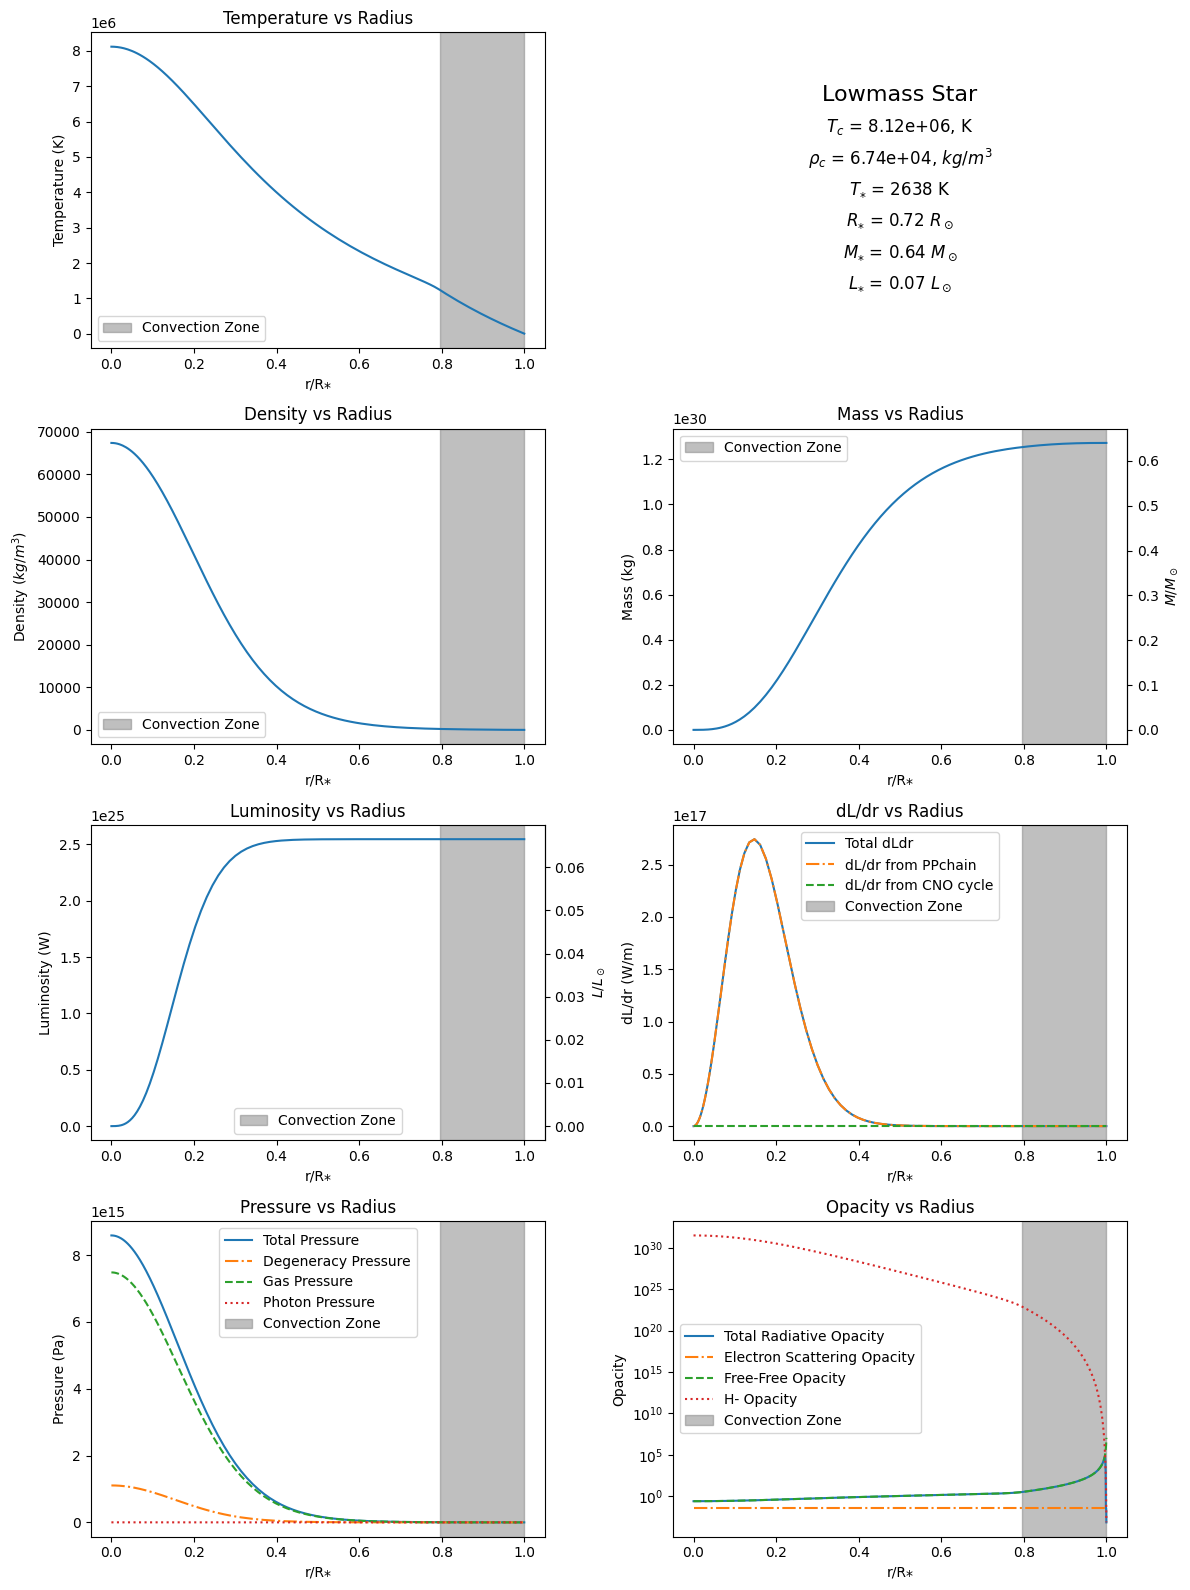

[(0, 54), (135, 187)]


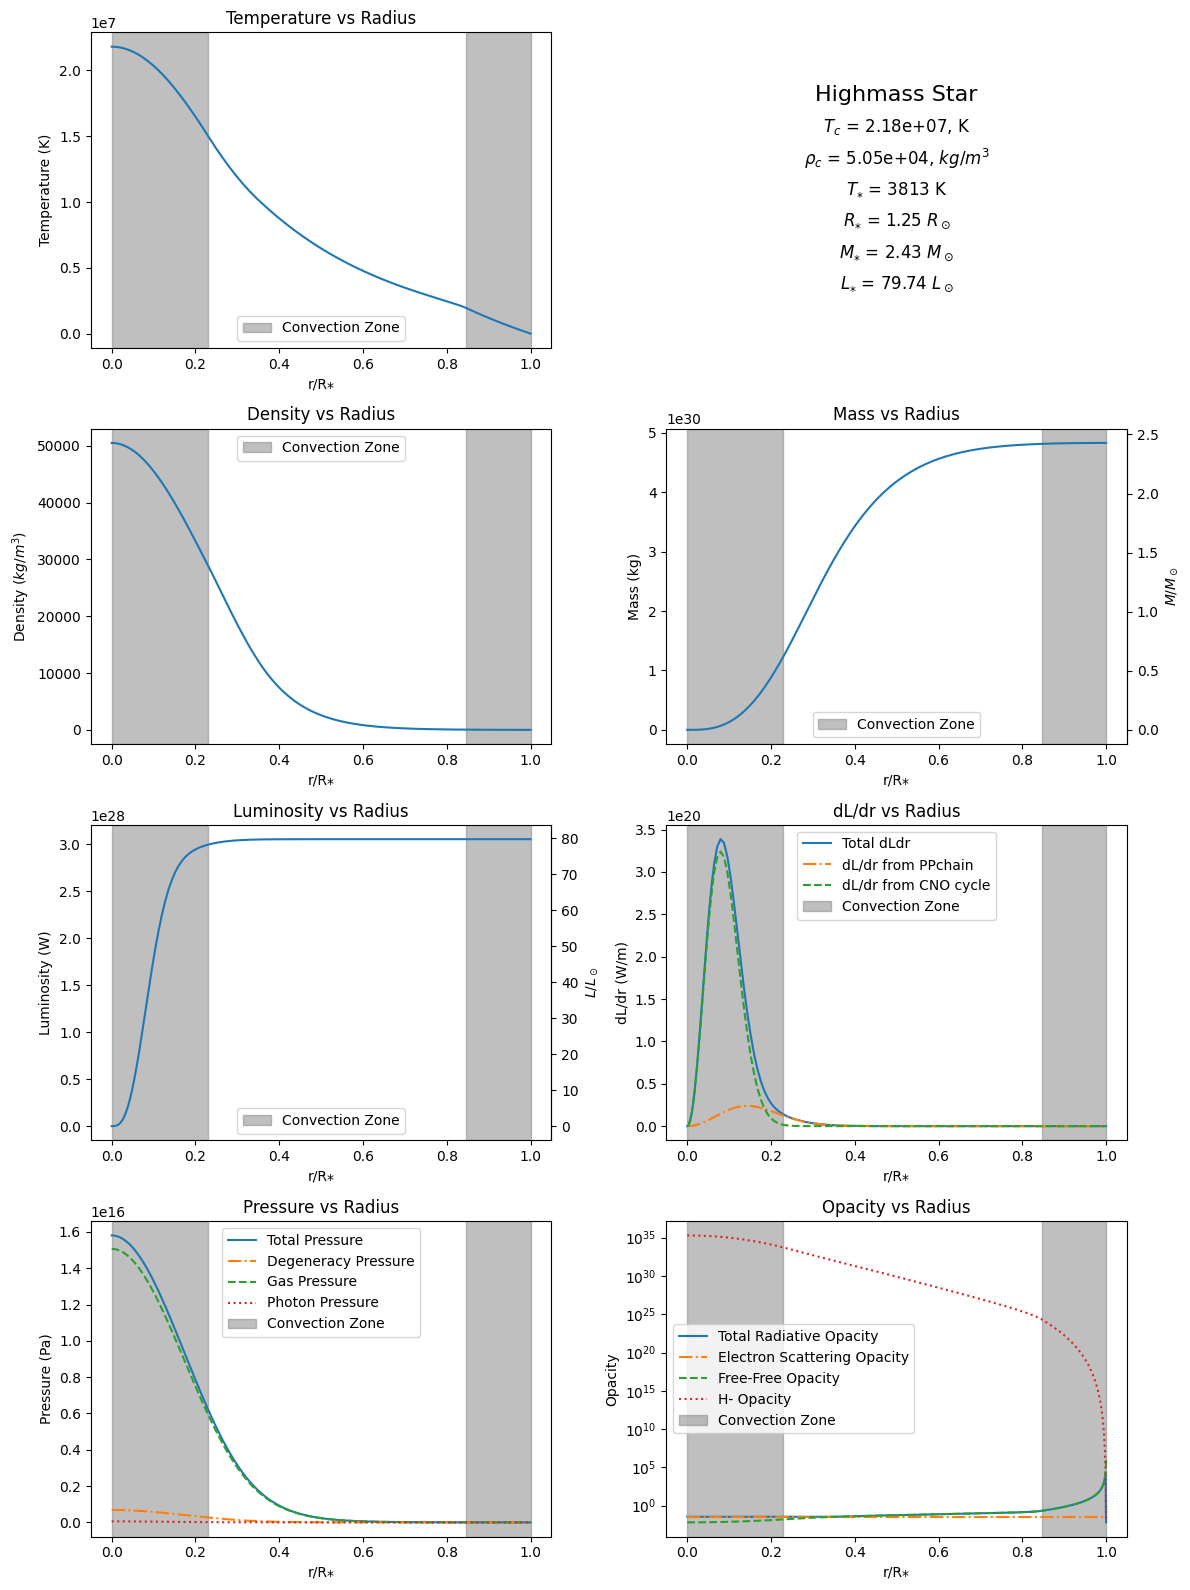

In [ ]:
#Generating plots to get information about the stars

def masstomsun(M):
    """
    Converts the mass of a star in kg to its mass in solar masses

    Parameters:
    M - Star mass in kg
    """
    return M/Msun

def msuntomass(M):
    """
    Converts the mass of a star in solar masses to its mass in kg

    Parameters:
    M - Star mass in solar masses
    """
    return M*Msun

def lumtolsun(L):
    """
    Converts the luminosity of a star in W to its luminosity in solar luminosity

    Parameters:
    L - Star luminosity in W
    """
    return L/Lsun

def lsuntolum(L):
    """
    Converts the luminosity of a star in solar luminosity to its luminosity in W

    Parameters:
    L - Star luminosity in solar luminosity
    """
    return L*Lsun

def dTdrzones(r, M, p, L, T, mag = False, n = 1.0, beta = 10.0):
    """
    Calculate whether the a certain value of r within a star lies within a radiative or convective zone.
    Value of 0 is a radiative zone, 1 is a convection zone

    Parameters:
    r - Radius
    M - Mass
    p - Density
    L - Luminosity
    T - Temperature
    mag - Magnetic field consideration, where "True" considers magnetic fields and "False" does not (default = False)
    n - Magnetic field dissipation rate (default = 1.0)
    beta - Peak magnetic field strength (default = 10.0)
    """
    d1 = 3.0*kr(p, T)*p*L/16.0/pi/a/c/T**3.0/r/r                #Radiative Transport
    d2 = (1.0-1.0/y)*T*G*M*p/P(p, T, M, L, mag, n, beta)/r/r    #Convective Transport
    if np.isnan(d1) or np.isnan(d2):                            #This if statement is just a debugger - large steps in the integrator often returns NAN
        print("NANS")
    if abs(d1) < abs(d2):
        return 0                                                #0 if radiative
    else:  
        return 1                                                #1 if convective


def plotting(vals, title):
    """
    Plots various features of a star as a function of the stars radius. Included graphs: temperature, density, mass, luminosity
    dL/dr, pressure, opacity.

    Parameters:
    vals - solution to pcrootlist()
    title - title for the set of graphs
    """
    rs = vals[-1]/vals[-1][-1]                                      #Creating a set of radius values (r/Rstar)

    T, p, M, L, tau, r = vals                                       #Unpacking the star solution to its various variables

    zones = []                                                      #Determining the indices radiative and convective zones throughout entire star
    for i in range(len(r)):
        zones.append(dTdrzones(r[i], M[i], p[i], L[i], T[i]))
    

    convecvals = []                                                 #Isolating convection zone indices
    for i in range(len(zones)):
        if zones[i] == 1:
            convecvals.append(i)
    
    conveczones = []                                                #Separating convection zones if consecutive items in convecvals
    zonemin = convecvals[0]                                         #are not consecutive integers
    zonemax = convecvals[-1]
    for i in range(len(convecvals)-1):
        if convecvals[i+1]-convecvals[i] > 1:
            zonemax = convecvals[i]
            conveczones.append((zonemin, zonemax))
            zonemin = convecvals[i+1]
            zonemax = convecvals[-1]
    conveczones.append((zonemin, zonemax))
    print(conveczones)


    fig, axs = plt.subplots(4, 2, figsize = (12,16))                #Creating subplots

    

    axs[0, 0].plot(rs, T)                                           #Temperature
    axs[0, 0].set_title('Temperature vs Radius')
    axs[0, 0].set_xlabel('r/R⁎')
    axs[0, 0].set_ylabel('Temperature (K)')

    axs[0, 1].axis('off')                                           #Title
    axs[0, 1].text(0.5, 0.8, f'{title} Star', ha = 'center', va = 'center', fontsize = 16, transform = axs[0, 1].transAxes)
    axs[0, 1].text(0.5, 0.7, f'$T_c$ = {T[0]:.2e}, K', ha = 'center', va = 'center', fontsize = 12, transform = axs[0, 1].transAxes)
    axs[0, 1].text(0.5, 0.6, f'$\\rho_c$ = {p[0]:.2e}, $kg/m^3$', ha = 'center', va = 'center', fontsize = 12, transform = axs[0, 1].transAxes)
    axs[0, 1].text(0.5, 0.5, f'$T_⁎$ = {T[-1]:.0f} K', ha = 'center', va = 'center', fontsize = 12, transform = axs[0, 1].transAxes)
    axs[0, 1].text(0.5, 0.4, f'$R_⁎$ = {r[-1]/Rsun:.2f} $R_\\odot$', ha = 'center', va = 'center', fontsize = 12, transform = axs[0, 1].transAxes)
    axs[0, 1].text(0.5, 0.3, f'$M_⁎$ = {M[-1]/Msun:.2f} $M_\\odot$', ha = 'center', va = 'center', fontsize = 12, transform = axs[0, 1].transAxes)
    axs[0, 1].text(0.5, 0.2, f'$L_⁎$ = {L[-1]/Lsun:.2f} $L_\\odot$', ha = 'center', va = 'center', fontsize = 12, transform = axs[0, 1].transAxes)



    axs[1, 0].plot(rs, p)                                           #Density
    axs[1, 0].set_title('Density vs Radius')
    axs[1, 0].set_xlabel('r/R⁎')
    axs[1, 0].set_ylabel('Density ($kg/m^3$)')

    axs[1, 1].plot(rs, M)                                           #Mass
    axs[1, 1].set_title('Mass vs Radius')
    axs[1, 1].set_xlabel('r/R⁎')
    axs[1, 1].set_ylabel('Mass (kg)')
    right1 = axs[1, 1].secondary_yaxis("right", functions = (masstomsun, msuntomass))
    right1.set_ylabel('$M/M_\\odot$', loc = 'center')

    axs[2, 0].plot(rs, L)                                           #Luminosity
    axs[2, 0].set_title('Luminosity vs Radius')
    axs[2, 0].set_xlabel('r/R⁎')
    axs[2, 0].set_ylabel('Luminosity (W)')
    right2 = axs[2, 0].secondary_yaxis("right", functions = (lumtolsun, lsuntolum))
    right2.set_ylabel('$L/L_\\odot$', loc = 'center')

    axs[2, 1].plot(rs, dLdr(r, p, T), label = 'Total dLdr')                             #dL/dr and its individual components
    axs[2, 1].plot(rs, dLdrpp(r, p, T),  ls = '-.', label = 'dL/dr from PPchain')
    axs[2, 1].plot(rs, dLdrcno(r, p, T), ls = '--', label = 'dL/dr from CNO cycle')
    axs[2, 1].set_xlabel('r/R⁎')
    axs[2, 1].set_ylabel('dL/dr (W/m)')
    axs[2, 1].set_title('dL/dr vs Radius')

    axs[3, 0].plot(rs, P(p, T), label = 'Total Pressure')                               #Pressure and its individual components
    axs[3, 0].plot(rs, Pdegen(p), label = 'Degeneracy Pressure', ls = '-.')
    axs[3, 0].plot(rs, Pgas(p, T), label = 'Gas Pressure', ls = '--')
    axs[3, 0].plot(rs, Pphoton(T), label = 'Photon Pressure', ls = ':')
    axs[3, 0].set_xlabel('r/R⁎')
    axs[3, 0].set_ylabel('Pressure (Pa)')
    axs[3, 0].set_title('Pressure vs Radius')

    axs[3, 1].plot(rs, kr(p, T), label = 'Total Radiative Opacity')                     #Opacity and its individual components
    axs[3, 1].hlines(kes, xmin = 0, xmax = 1, label = 'Electron Scattering Opacity', ls = '-.', color = 'tab:orange')
    axs[3, 1].plot(rs, kff(p, T), label = 'Free-Free Opacity', ls = '--', color = 'tab:green')
    axs[3, 1].plot(rs, kH(p, T), label = 'H- Opacity', ls = ':', color = 'tab:red')
    axs[3, 1].set_xlabel('r/R⁎')
    axs[3, 1].set_yscale('log')
    axs[3, 1].set_ylabel('Opacity')
    axs[3, 1].set_title('Opacity vs Radius')

    for j, ax in enumerate(axs.flatten()):                                               #Shading in convection zones, skipping title plot
        if j == 1:
            continue
        for i in conveczones:
            if i == conveczones[0]:
                ax.axvspan(rs[i[0]], rs[i[1]], color = 'gray', alpha = 0.5, zorder = 0, label = 'Convection Zone')
            else:
                ax.axvspan(rs[i[0]], rs[i[1]], color = 'gray', alpha = 0.5, zorder = 0)
            ax.legend()

    plt.tight_layout()
    plt.show()

plotting(lowmass, 'Lowmass')
plotting(highmass, 'Highmass')